In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

# 1. Charger les données
df = pd.read_csv('merged_sensor_data.csv')

# 2. Convertir le Timestamp en objet datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])

# 3. Trier par date (au cas où)
df = df.sort_values('Timestamp')

# 4. Gérer les données manquantes (NaN)
# Pour le Deep Learning et la visualisation, l'interpolation linéaire
# est souvent la meilleure méthode pour les capteurs
df_clean = df.copy()
numeric_cols = ['Temperature', 'Humidity', 'Moisture', 'Light', 'Gas']
df_clean[numeric_cols] = df_clean[numeric_cols].interpolate(method='linear')

# Afficher les premières lignes
print("Aperçu des données :")
display(df_clean.head())

Aperçu des données :


,Timestamp,Temperature,Humidity,Moisture,Light,Gas
0,2026-03-19 10:17:44,26.7,43.0,72.57,53.3,8.9
1177,2026-03-19 10:17:44,26.7,43.0,72.57,53.3,8.9
1178,2026-03-19 10:30:45,26.7,43.0,72.67,55.0,8.9
1,2026-03-19 10:30:45,26.7,43.0,72.67,55.0,8.9
2,2026-03-19 10:35:45,26.7,43.0,72.61,55.0,8.9


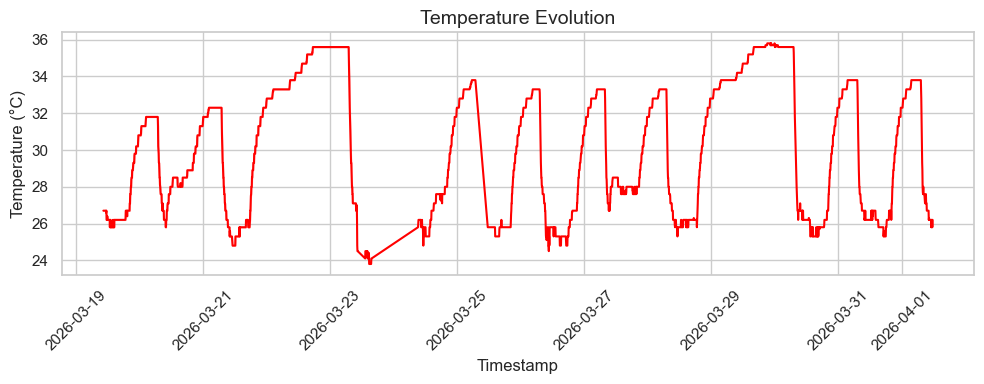

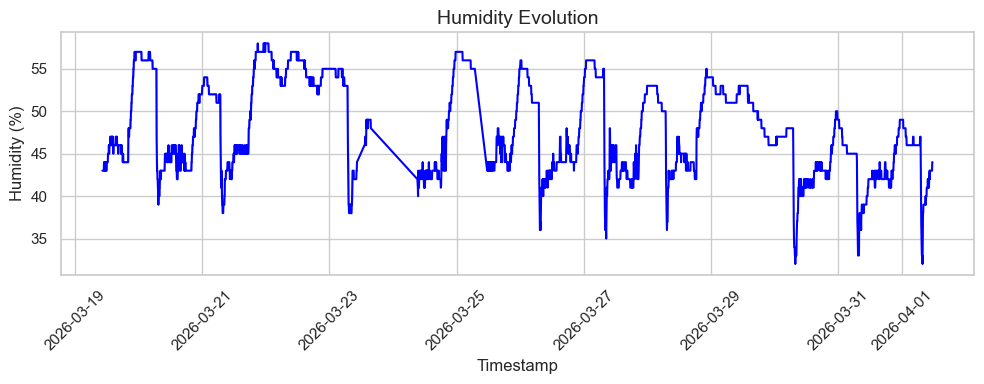

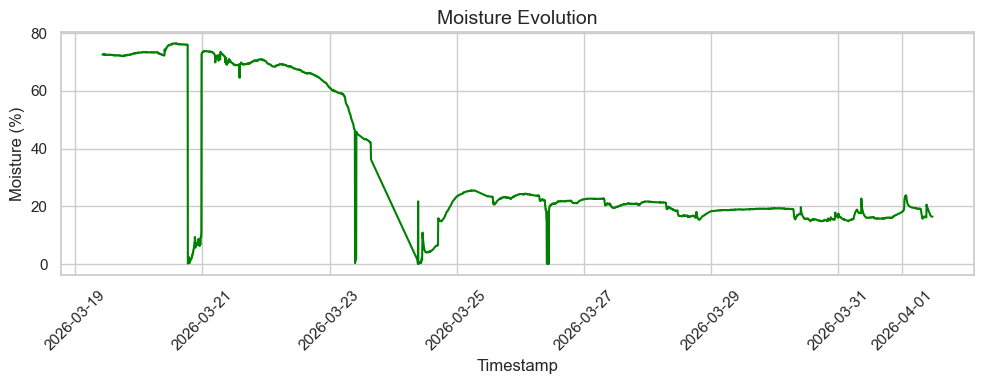

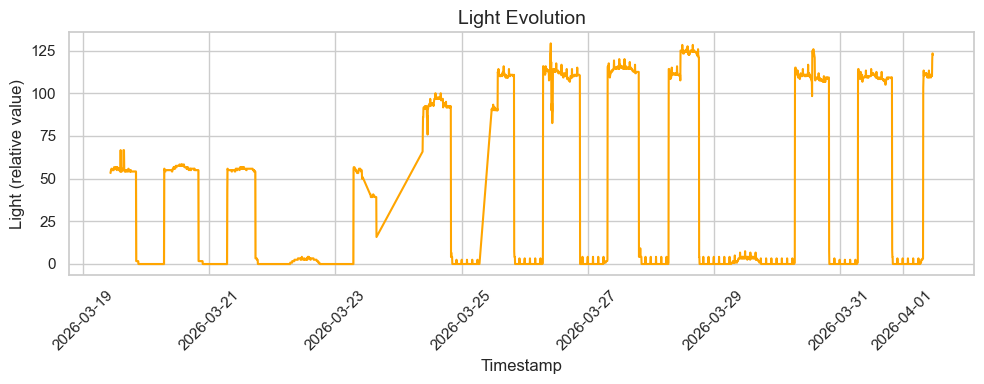

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuration du style
sns.set(style="whitegrid")

variables = ['Temperature', 'Humidity', 'Moisture', 'Light']
unit = [' (°C)', ' (%)', ' (%)', ' (relative value)']
colors = ['red', 'blue', 'green', 'orange']

for i, var in enumerate(variables):
    # 1. Create a new figure for each variable
    plt.figure(figsize=(10, 4))

    # 2. Generate the plot
    sns.lineplot(data=df_clean, x='Timestamp', y=var, color=colors[i])

    # 3. Add formatting
    plt.title(f'{var} Evolution', fontsize=14)
    plt.ylabel(var + unit[i])
    plt.xlabel('Timestamp')
    plt.xticks(rotation=45)
    plt.tight_layout()

    # 4. Save the figure as SVG
    plt.savefig(f"{var}_plot.svg", dpi=300)

    # 5. Show and then close the plot to free up memory
    plt.show()
    plt.close()